In [6]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import copy
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) # normalização do imagenet
])

train_path = './cifake/train'
train_dataset = ImageFolder(root=train_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_path = './cifake/test'
val_dataset = ImageFolder(root=val_path, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

class ResNet50(nn.Module):
    def __init__(self,):
        super(ResNet50, self).__init__()
        
        self.base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        
        num_features = self.base_model.fc.in_features # número de features da camada final do ResNet50
        self.base_model.fc = nn.Identity() # substitui a camada final (fc) por uma identidade para extrair as features
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(num_features),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.5),    
            nn.Linear(256, 64),          
            nn.ReLU(),
            nn.Linear(64, 1)             
        )

    def forward(self, x):
        x = self.base_model(x)
        x = self.classifier(x)
        return x

model = ResNet50().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adamax(model.parameters(), lr=0.001)

def train_model(model, optimizer, max_epochs=20, patience=3):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        print(f'\nEpoch {epoch+1}/{max_epochs}')

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            correct = 0 
            total = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.unsqueeze(1).float().to(device)

                optimizer.zero_grad()

                # calcula o gradiente só se tiver em treino
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item()
                
                with torch.no_grad():
                    predicted = torch.round(torch.sigmoid(outputs.data)) 
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            epoch_loss = running_loss / len(dataloader)
            epoch_acc = correct / total

            print(f'{phase.capitalize()} -> Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

            if phase == 'val':
                if epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict()) # copia o melhor modelo
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    print(f'Sem melhoria por {epochs_no_improve} época(s).')

        if epochs_no_improve >= patience:
            print('\nEarly Stopping ativado! Interrompendo o treinamento.')
            break

    model.load_state_dict(best_model_wts)
    return model

print("\nTreinando classifier")
for param in model.base_model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

optimizer_fc = optim.Adamax(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

model = train_model(model, optimizer_fc, max_epochs=20, patience=1)

def metrics(model, dataloader, device, dataset_name):
    model.eval() 
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            
            outputs = model(inputs)
        
            preds = torch.round(torch.sigmoid(outputs))
            
            all_preds.extend(preds.squeeze().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    print("-------------------------------------")
    print(f"Relatório Final: {dataset_name}")
    
    report = classification_report(all_labels, all_preds, target_names=['Fake', 'Real'], digits=4)
    print(report)

metrics(model, val_loader, device, "Teste")

metrics(model, train_loader, device, "Treino")

print("\n==================Fine tuning==================")
for param in model.base_model.parameters():
    param.requires_grad = True

optimizer_full = optim.Adamax(model.parameters(), lr=0.001)

model = train_model(model, optimizer_full, max_epochs=20, patience=1)

metrics(model, val_loader, device, "Teste")

metrics(model, train_loader, device, "Treino")



Treinando classifier

Epoch 1/20
Train -> Loss: 0.4425, Accuracy: 0.7910
Val -> Loss: 0.3857, Accuracy: 0.8250

Epoch 2/20
Train -> Loss: 0.4029, Accuracy: 0.8153
Val -> Loss: 0.3706, Accuracy: 0.8334

Epoch 3/20
Train -> Loss: 0.3855, Accuracy: 0.8254
Val -> Loss: 0.3583, Accuracy: 0.8375

Epoch 4/20
Train -> Loss: 0.3753, Accuracy: 0.8310
Val -> Loss: 0.3512, Accuracy: 0.8444

Epoch 5/20
Train -> Loss: 0.3675, Accuracy: 0.8357
Val -> Loss: 0.3452, Accuracy: 0.8506

Epoch 6/20
Train -> Loss: 0.3614, Accuracy: 0.8386
Val -> Loss: 0.3419, Accuracy: 0.8507

Epoch 7/20
Train -> Loss: 0.3559, Accuracy: 0.8426
Val -> Loss: 0.3388, Accuracy: 0.8508

Epoch 8/20
Train -> Loss: 0.3519, Accuracy: 0.8445
Val -> Loss: 0.3306, Accuracy: 0.8542

Epoch 9/20
Train -> Loss: 0.3473, Accuracy: 0.8464
Val -> Loss: 0.3308, Accuracy: 0.8571
Sem melhoria por 1 época(s).

Early Stopping ativado! Interrompendo o treinamento.
-------------------------------------
Relatório Final: Teste
              precision 

In [ ]:
import os
import numpy as np

MAX_ERROS = 500

def desnormalizar(tensor): # reverte normalização
    inp = tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    return np.clip(inp, 0, 1)

erros = 0

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.unsqueeze(1).float().to(device)

        outputs = model(inputs)
        preds = torch.round(torch.sigmoid(outputs))

        for i in range(inputs.size(0)):
            if preds[i] != labels[i]:
                verdadeiro = class_names[int(labels[i].item())]
                previsao = class_names[int(preds[i].item())]
                
                img_visivel = desnormalizar(inputs[i])
                
                file_name = f"Era_{verdadeiro}_Previu_{previsao}_{erros+1:03d}.png"
                path = os.path.join('./erros', file_name)
                
                plt.imsave(path, img_visivel)
                
                erros += 1
                
                if erros >= MAX_ERROS:
                    break
        
        if erros >= MAX_ERROS:
            break

print(f"{erros} imagens salvas")

500 imagens salvas


era fake previu real


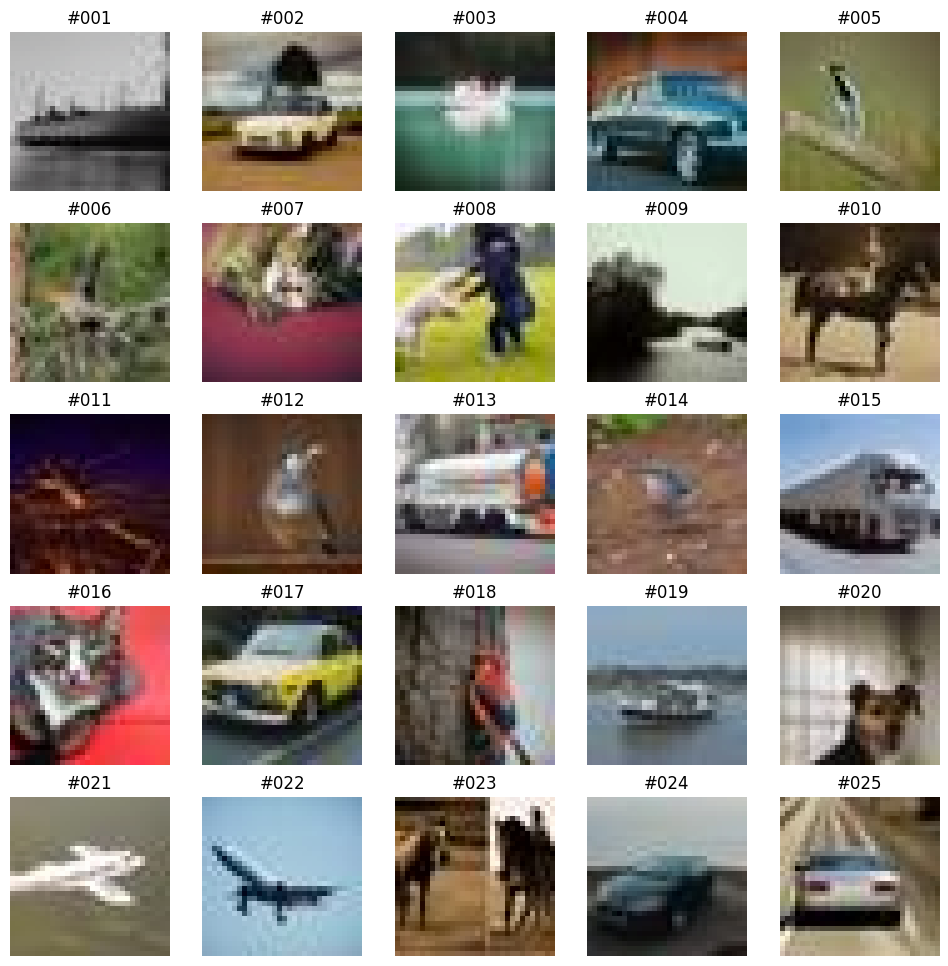

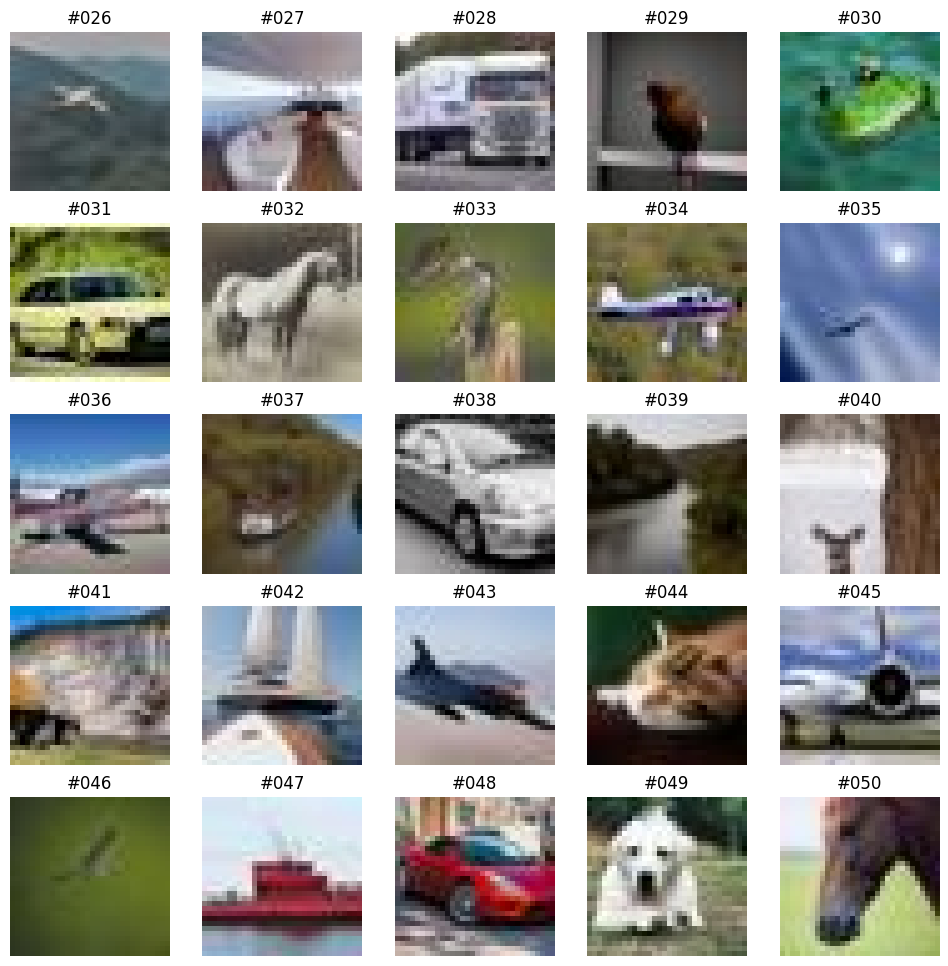

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

errors_path = './erros'
print("era fake previu real")
for plot in range(2):
    
    fig, axes = plt.subplots(5, 5, figsize=(12, 12))

    for i, ax in enumerate(axes.flat):
        img_index = (plot * 25) + i + 1
    
        file_name = f"Era_FAKE_Previu_REAL_{img_index:03d}.png"
        path = os.path.join(errors_path, file_name)
        
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(f"#{img_index:03d}")
            
        ax.axis('off') 
    
    plt.show()

era real previu fake


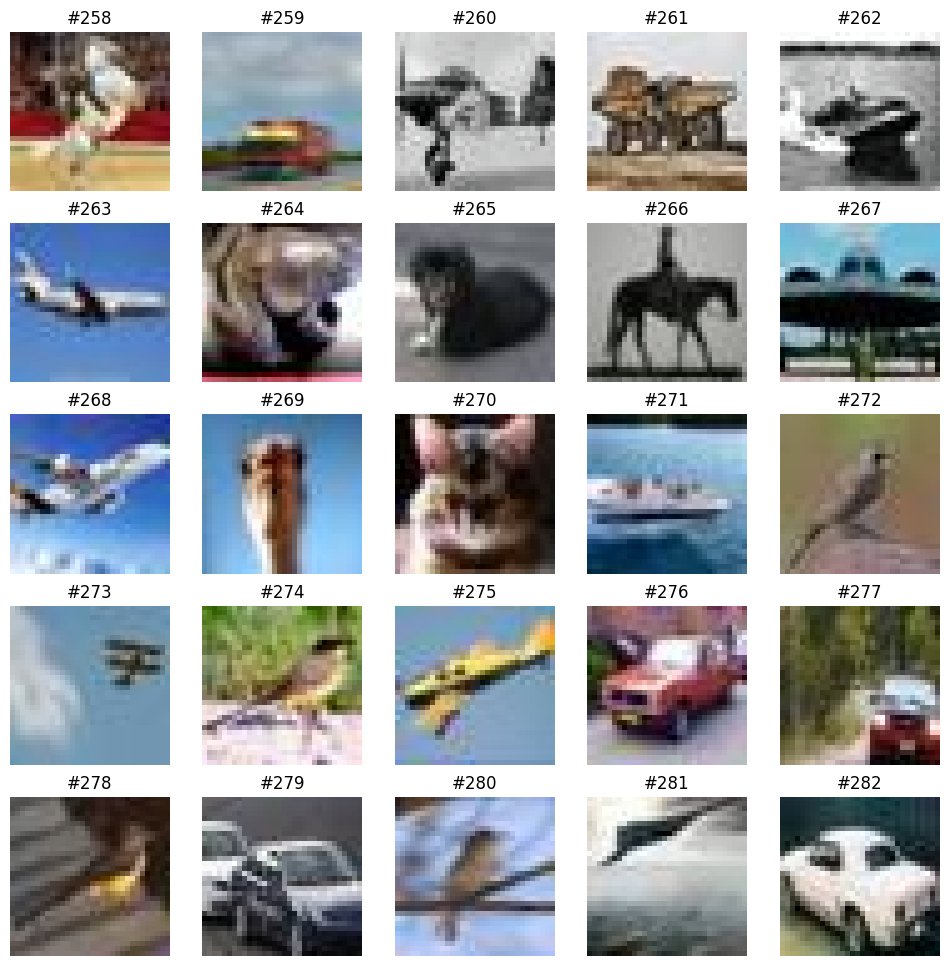

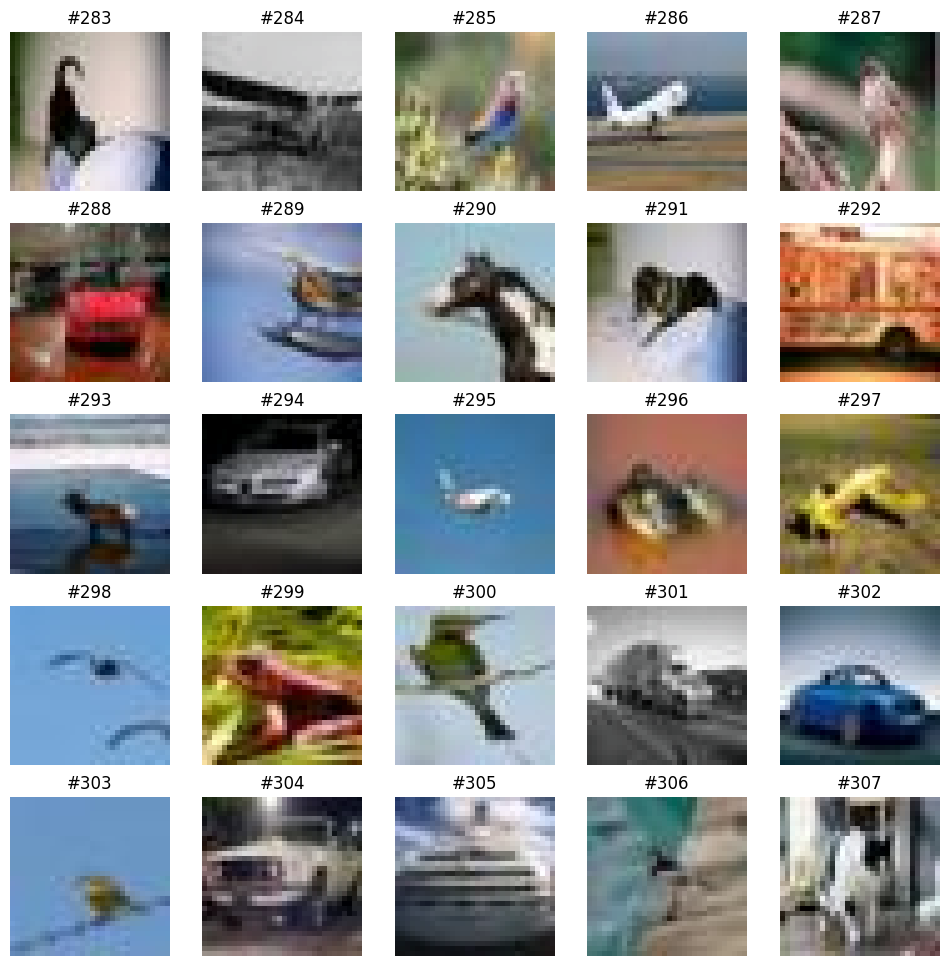

In [ ]:
errors_path = './erros'
print("era real previu fake")

for plot in range(2):
    
    fig, axes = plt.subplots(5, 5, figsize=(12, 12))


    for i, ax in enumerate(axes.flat):
        img_index = 257 + (plot * 25) + i + 1
    
        file_name = f"Era_REAL_Previu_FAKE_{img_index:03d}.png"
        path = os.path.join(errors_path, file_name)
        
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(f"#{img_index:03d}")
            
        ax.axis('off') 
    
    
    plt.show()